In [13]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


import warnings

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def normalize2(row, mean_df, std_df, athlete_id):
    '''
    Normalize the data using z-score normalization.
    '''
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

def getMeanStd(data):
    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getBalancedSubset(X_train, samplesPerClass):
    '''
    Create a balanced subset of the data by sampling from each athlete's data.
    '''
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()
    
    stats = pd.DataFrame(X_train[['Athlete ID','injury']].groupby(['Athlete ID','injury']).size().reset_index(name='counts'))
    stats = pd.DataFrame(stats[['Athlete ID']].groupby(['Athlete ID']).size().reset_index(name='counts'))
    stats.drop(stats[stats['counts'] < 2].index, inplace=True)
    athleteList = stats['Athlete ID'].unique()

    samplesPerAthlete = int(np.floor(samplesPerClass) / len(athleteList))

    for athlete in athleteList:
        if unhealthySet.empty:
            unhealthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete, replace=True)
        else:
            unhealthySet = pd.concat([unhealthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete,replace=True)], ignore_index=True)
        if healthySet.empty:
            healthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete, replace=True)
        else:
            healthySet = pd.concat([healthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete,replace=True)], ignore_index=True)


    balancedSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return balancedSet

def getregsubset(X_train, samplesPerClass):
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()

    unhealthySet = X_train[X_train['injury'] == 0].sample(samplesPerClass, replace=True)
    healthySet = X_train[X_train['injury'] == 1].sample(samplesPerClass, replace=True)


    regSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return regSet


def preparedata(df,test_athletes):
    '''
    Prepare the data for training and testing.
    This includes normalization, creating a balanced subset of the data, and splitting into training and testing sets.
    '''
    X_test_original = df[df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
    X_train_original = df[~df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy

    X_train_means, X_train_std = getMeanStd(X_train_original)
    X_test_means, X_test_std = getMeanStd(X_test_original)
    X_train_balanced = getBalancedSubset(X_train_original.copy(), 2048)
    
    # Set target variable for testing and training
    y_train = X_train_balanced['injury']
    y_test = X_test_original['injury']

    # Apply normalization to the balanced training data
    X_train_norm = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
    X_train_norm = X_train_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

    # Apply normalization to the test data using the testing statistics
    # Note this is a source of data leakage! but the alternative is not feasible
    X_test_norm = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
    X_test_norm = X_test_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


    return y_train, y_test, X_train_norm, X_test_norm

def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)

def eval(model, y_true, X, y_pred, **params):
    '''
    Produce key evaluation metrics without visualisations.
    '''
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, Recall(most important): {recall:.3f}")
   
    return (accuracy,recall,roc_auc)

def run_exps(df,test_set, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = preparedata(df, test_set)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model
    
    


In [16]:
def validate_data(df, step_name):
    """
    Validate the DataFrame for NaN values and unexpected columns.
    """
    if df.isna().any().any():
        print(f"[ERROR] NaN values found after step: {step_name}")
        print(df.isna().sum())
        raise ValueError(f"NaN values detected after {step_name}")
    print(f"[INFO] Data validation passed after step: {step_name}")
    print(f"[INFO] Columns: {list(df.columns)}")
    print(f"[INFO] Shape: {df.shape}")

In [21]:
def run_cv_holdout_exps(df, n_splits=5, n_runs=5, holdout_size=0.2, sample_size=4096, **params):
    '''
    Run experiments with both hold-out validation and k-fold cross-validation
    Saves the model that performs best on the holdout set (high recall with acceptable accuracy)
    '''
    all_cv_results = []
    all_holdout_results = []
    best_model = None
    best_recall = 0
    best_accuracy = 0
    run = 0 
    
    
    
    while run < n_runs:
        # First split into train+cv and holdout sets
        validate_data(df, f"start of run {run+1}")
        df_balanced = getregsubset(df, sample_size)
        df_means, df_std = getMeanStd(df_balanced)
        
        # Split into holdout and training sets
        train_df, holdout_df = train_test_split(
            df_balanced, 
            test_size=holdout_size,
            stratify=df_balanced['injury'],
            random_state=run
        )
        
        # Normalize training data
        X_train = train_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_train = train_df['injury']
        X_train = X_train.drop(columns=['injury','Athlete ID', 'Date'], errors='ignore')
        
        # Normalize holdout data
        X_holdout = holdout_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_holdout = holdout_df['injury']
        X_holdout = X_holdout.drop(columns=['injury','Athlete ID', 'Date'], errors='ignore')
        
        validate_data(X_train, f"before cross validation  X_train{run}")
        validate_data(X_holdout, f"before cross validation  X_holdout{run}")
        

        # Create stratified k-fold for training data
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run)
        
        # Perform k-fold CV on training data
        fold_results = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_fold_train, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = train_model(X_fold_train, y_fold_train, **params)
            y_pred = model.predict(X_val)
            print(f"val for Fold {fold+1} results:")
            results = eval(model, y_val, X_val, y_pred)  # Using non-visual evaluation
            fold_results.append(results)
            
            if results[1] > best_recall and results[0] > 0.6:
                best_model = model
                best_recall = results[1]
                best_accuracy = results[0]
        
        # Average CV results for this run
        cv_run_results = np.mean(fold_results, axis=0)
        all_cv_results.append(cv_run_results)
        
        
        
        # Train final model on all training data
        final_model = train_model(X_train, y_train, **params)
        try:
            holdout_pred = final_model.predict(X_holdout)
            holdout_results = eval(final_model, y_holdout, X_holdout, holdout_pred)
            all_holdout_results.append(holdout_results)
            
            # Track best model based on holdout performance
            print( f' does this model beat previous one?accuracy = {holdout_results[0]:.3f}, recall = {holdout_results[1]:.3f}, roc_auc = {holdout_results[2]:.3f}')
            if (holdout_results[1] > best_recall and  # Better recall
                holdout_results[0] > 0.6):  # Better overall
                best_model = final_model
                best_recall = holdout_results[1]
                best_accuracy = holdout_results[0]
                print(f"\nNew best model found in run {run+1}:")
                print(f"Holdout - Accuracy: {holdout_results[0]:.3f}, Recall: {holdout_results[1]:.3f}, ROC AUC: {holdout_results[2]:.3f}")
        except ValueError as e:
            print ('/n/n/n error/n/n/n')
            print(X_holdout)
            break
      
        print(f"\nRun {run+1}:")
        
        print(f"CV - Accuracy: {cv_run_results[0]:.3f}, Recall: {cv_run_results[1]:.3f}, ROC AUC: {cv_run_results[2]:.3f}")
        print(f"Holdout - Accuracy: {holdout_results[0]:.3f}, Recall: {holdout_results[1]:.3f}, ROC AUC: {holdout_results[2]:.3f}")
        run += 1
        '''
    # Print overall performance
    print("\nOverall CV Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_cv_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_cv_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_cv_results]):.3f}")
    
    print("\nOverall Holdout Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_holdout_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_holdout_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_holdout_results]):.3f}")
    

    # Add information about the best model's performance
    print("\nBest Model Performance (on holdout):")
    print(f"Recall: {best_recall:.3f}")
    print(f"Accuracy: {best_accuracy:.3f}")
    '''
    return best_model # Also return normalization parameters for future use

In [3]:
dfday = pd.read_csv('../data/combodf.csv')
dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)

In [17]:
dfday_55 = dfday.drop(dfday[dfday['Athlete ID'] == 55].index)

In [ ]:

best_model = run_cv_holdout_exps(dfday_55, 
                                             n_splits=5, 
                                             n_runs=5,
                                             holdout_size=0.2,
                                             sample_size=4096,
                                             C=0.01, 
                                             penalty='elasticnet', 
                                             solver='saga', 
                                             l1_ratio=0.5)



[INFO] Data validation passed after step: start of run 1
[INFO] Columns: ['Athlete ID', 'Date', 'injury', 'Day1 total km', 'Day1 km z3+', 'Day1 km z5', 'Day2-3 nr.sessions', 'Day2-3 total km', 'Day2-3 km z3+', 'Day2-3 km z5', 'Day4-7 nr.sessions', 'Day4-7 total km', 'Day4-7 km z3+', 'Week1 max km one day', 'Week1 total km z3+', 'Week1 max km Z3+ one day', 'Week2 max km one day', 'Week2 total km z3+', 'Week2 max km Z3+ one day', '5day/3W tot km ratio', '5day/3W proportion km z3+', '5day/3W nr. sessions ratio', '5day/3W hours alternative training ratio', 'ACWR']
[INFO] Shape: (42632, 24)
[INFO] Data validation passed after step: before cross validation  X_train0
[INFO] Columns: ['5day/3W hours alternative training ratio', '5day/3W nr. sessions ratio', '5day/3W proportion km z3+', '5day/3W tot km ratio', 'ACWR', 'Day1 km z3+', 'Day1 km z5', 'Day1 total km', 'Day2-3 km z3+', 'Day2-3 km z5', 'Day2-3 nr.sessions', 'Day2-3 total km', 'Day4-7 km z3+', 'Day4-7 nr.sessions', 'Day4-7 total km', '

In [30]:
 # Save model and normalization parameters
with open('../models/mvp2best_logistic_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [9]:
dfday.head()

,Athlete ID,Date,injury,Day1 total km,Day1 km z3+,Day1 km z5,Day2-3 nr.sessions,Day2-3 total km,Day2-3 km z3+,Day2-3 km z5,...,Week1 total km z3+,Week1 max km Z3+ one day,Week2 max km one day,Week2 total km z3+,Week2 max km Z3+ one day,5day/3W tot km ratio,5day/3W proportion km z3+,5day/3W nr. sessions ratio,5day/3W hours alternative training ratio,ACWR
0,0,0,0,5.8,0.6,0.6,1.0,0.0,0.0,0.0,...,13.5,6.4,9.9,3.9,3.2,0.084,0.254,0.214,0.26,0.263197
1,0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,14.2,7.0,9.9,5.0,3.2,0.220,1.529,0.200,0.26,1.014703
2,0,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,14.2,7.0,9.9,5.0,3.2,0.220,1.529,0.286,0.50,1.014703
3,0,3,0,0.0,0.0,0.0,2.0,16.4,10.0,0.0,...,14.2,7.0,9.9,5.0,3.2,0.290,1.218,0.267,0.50,1.233508
4,0,4,0,0.0,0.0,0.0,2.0,16.4,10.0,0.0,...,7.8,6.6,13.8,10.7,6.4,0.252,1.152,0.267,0.50,1.052315


# Ensuring it produces a working model

In [ ]:
from apicall_input import main_api_call 
from data_extraction_v2 import main_extract_transform
# call the two preprocessing functions
start_date, end_date, df_memory = main_api_call(email = '', password = '')
df = main_extract_transform(start_date, end_date, df_memory)

Garmin Connect API - Activity Downloader
Login successful!
Activity data for 'indoor_cardio|21-08-2025|20130260263.csv' loaded into DataFrame.
Activity data for 'running|20-08-2025|20116740584.csv' loaded into DataFrame.
Activity data for 'indoor_cardio|19-08-2025|20111594169.csv' loaded into DataFrame.
Activity data for 'indoor_cardio|18-08-2025|20096824015.csv' loaded into DataFrame.
Activity data for 'indoor_cardio|15-08-2025|20065742282.csv' loaded into DataFrame.
Activity data for 'indoor_cardio|14-08-2025|20059835179.csv' loaded into DataFrame.
Activity data for 'treadmill_running|13-08-2025|20044942352.csv' loaded into DataFrame.
Activity data for 'indoor_cardio|12-08-2025|20034672816.csv' loaded into DataFrame.
Activity data for 'walking|10-08-2025|20012275661.csv' loaded into DataFrame.
Activity data for 'running|10-08-2025|20010223403.csv' loaded into DataFrame.
Activity data for 'treadmill_running|08-08-2025|19990936196.csv' loaded into DataFrame.
Activity data for 'indoor_c

In [7]:
# Return statistics relating to user data
def normalize_user(row, mean_df, std_df):
    z = (row - mean_df) / std_df
    return z

# Calculate the means and standard deviations of all healthy events per athlete
def getMeanStd_user(data):
    # drop the date column while the normalisaition is going on
    data_no_date = data.drop(columns =['Date'], errors = 'ignore')
    mean = data_no_date.mean()
    std = data_no_date.std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

user_test_means, user_test_std = getMeanStd_user(df.copy())
# Normalize the data
user_normalized = df.apply(lambda x: normalize_user(x, user_test_means,user_test_std), axis=1)
user_normalized = user_normalized.drop(columns=[ 'Date'], errors='ignore')


In [23]:
probs = best_model.predict_proba(user_normalized)[:, 1]

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


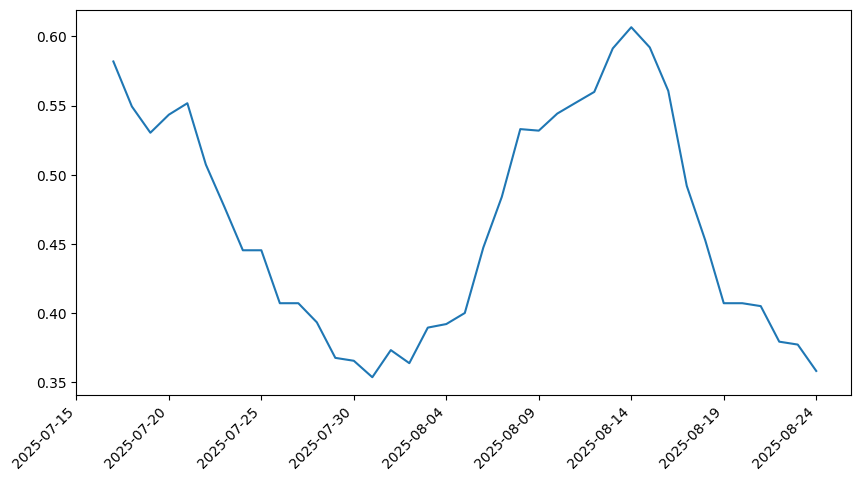

In [25]:
# create a df of predictions using the date column from dfday_user and the predictions

df['injury probabilities'] = probs
df[['Date','injury probabilities']].head(30)

# Save the predictions to a CSV file
#df.to_csv('user activity_data_with_predictions.csv', index=False)


plt.figure(figsize=(10,5))
plt.plot(df['Date'],df['injury probabilities'].rolling(window=3).mean())
plt.xticks(df['Date'][::5], rotation=45, ha='right')
plt.savefig('rolling_mean_plot.png')
# save and display the images
plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 23 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Date                                      41 non-null     object 
 1   Day1 total km                             41 non-null     float64
 2   Day1 km z3+                               41 non-null     float64
 3   Day1 km z5                                41 non-null     float64
 4   Day2-3 nr.sessions                        41 non-null     float64
 5   Day2-3 total km                           41 non-null     float64
 6   Day2-3 km z3+                             41 non-null     float64
 7   Day2-3 km z5                              41 non-null     float64
 8   Day4-7 nr.sessions                        41 non-null     float64
 9   Day4-7 total km                           41 non-null     float64
 10  Day4-7 km z3+                           

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


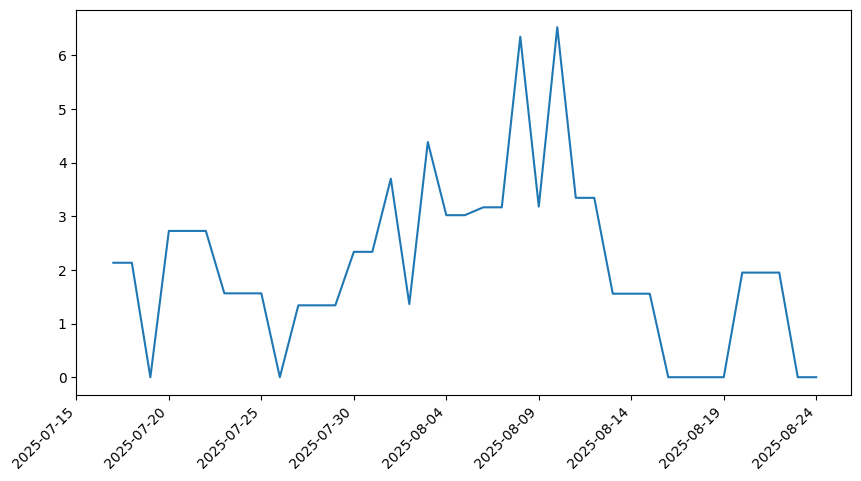

In [28]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'],df['Day1 total km'].rolling(window=3).mean())
plt.xticks(df['Date'][::5], rotation=45, ha='right')

# save and display the images
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


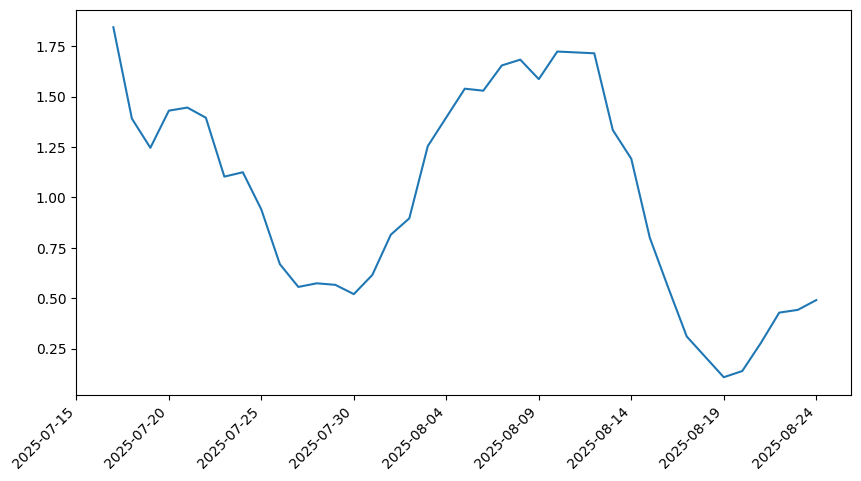

In [29]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'],df['ACWR'].rolling(window=3).mean())
plt.xticks(df['Date'][::5], rotation=45, ha='right')

# save and display the images
plt.show()